C:\Users\tiago\AppData\Local\Temp\ipykernel_15288\3357813966.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr1, wave1 = wavfile.read("./waveforms/AKWF_nes/AKWF_nes_triangle.wav")
C:\Users\tiago\AppData\Local\Temp\ipykernel_15288\3357813966.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr2, wave2 = wavfile.read("./waveforms/AKWF_nes/AKWF_nes_square.wav")


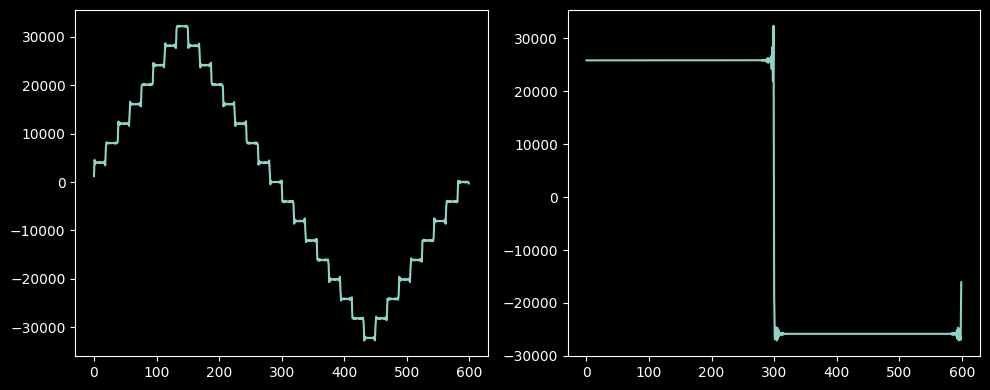

In [45]:
from scipy.io import wavfile
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')

sr1, wave1 = wavfile.read("./waveforms/AKWF_nes/AKWF_nes_triangle.wav")
sr2, wave2 = wavfile.read("./waveforms/AKWF_nes/AKWF_nes_square.wav")

fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].plot(wave1)
axs[1].plot(wave2)

plt.tight_layout()
plt.show()


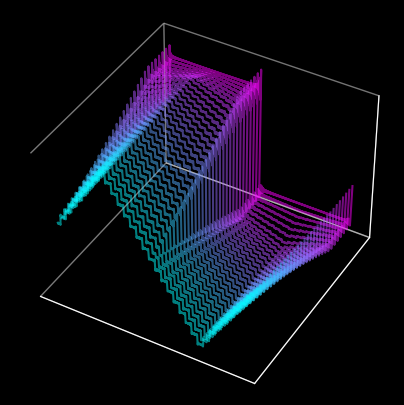

In [89]:
import numpy as np

def morph_waves(wave1, wave2, steps=32, samples=2048):  
    def detect_fundamental(mag, threshold_ratio = 0.2):
        mag = mag.copy()
        mag[0] = 0
        fundamental = np.argmax(mag)
        return max(fundamental, 1)
        #threshold = np.max(mag) * threshold_ratio
        #candidates = np.where(mag > threshold)[0]
        #if len(candidates) == 0:
        #    return 1  # fallback
        #return candidates[0]
      
    def align_wave(wave):
        spec = np.fft.rfft(wave)
        mag = np.abs(spec)

        mag[0] = 0 # remove dc
        fundamental = detect_fundamental(mag)

        if fundamental == 0:
            return wave

        phase = np.angle(spec[fundamental])
        k = np.arange(len(spec))

        # remove fundamental phase
        spec *= np.exp(-1j * phase * k / fundamental)

        # rotate 90 degrees so waveform starts at zero crossing
        spec *= np.exp(-1j * (np.pi/2) * k / fundamental)

        return np.fft.irfft(spec, len(wave))
    
    wave1 = align_wave(wave1)
    wave2 = align_wave(wave2)

    # take FFT
    spec1 = np.fft.rfft(wave1)
    spec2 = np.fft.rfft(wave2)
    
    #mag1 = np.abs(spec1)
    #mag2 = np.abs(spec2)

    #phase1 = np.angle(spec1)
    #phase2 = np.angle(spec2)

    # avoid phase wrap jumps
    #phase2 = phase1 + np.unwrap(phase2 - phase1)

    # generate morph steps
    morphed_waves = []
    for i in range(steps):
        alpha = i / (steps - 1)

        #mag = (1 - alpha) * mag1 + alpha * mag2
        #phase = (1 - alpha) * phase1 + alpha * phase2
        #spec = mag * np.exp(1j * phase)
        spec = (1 - alpha) * spec1 + alpha * spec2

        wave = np.fft.irfft(spec, n=samples)
        wave /= np.max(np.abs(wave))

        morphed_waves.append(wave)


    return morphed_waves


def plot_wavetable(wavetable, alpha=0.75):
    wavetable = np.array(wavetable)
    numtables = len(wavetable)

    # Colormap
    cmap = plt.get_cmap('cool')
    colors = [cmap(i) for i in np.linspace(0, 1, numtables)]

    # Prepare 3D figure
    fig = plt.figure(figsize=(5,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor("black")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    for i in reversed(range(len(wavetable))):
        wave = wavetable[i]
        x = np.arange(len(wave))           # sample index
        y = np.full(len(wave), i * 1)      # offset along Y
        z = wave                           # amplitude
        ax.plot(x, y, z, color=colors[i], alpha=alpha)

    ax.view_init(elev=40, azim=-60)
    plt.show()
    
def sort_waves(waves, threshold=0.05, samples=None):
    scores = []
    
    for wave in waves:
        n = samples or len(wave)
        spec = np.fft.rfft(wave, n=n)
        mag = np.abs(spec)
        mag /= np.max(mag)  # normalize
    
        # ignore DC
        mag[0] = 0.0
    
        # Count harmonics above threshold
        harmonics = mag > threshold
        num_harmonics = np.sum(harmonics)
    
        # harmonic indices (0,1,2,...)
        harmonic_indices = np.arange(len(mag))
    
        # Weight amplitudes by harmonic index
        amplitude_penalty = np.sum(mag[harmonics] * harmonic_indices[harmonics])
    
        # Simplicity score
        score = num_harmonics * amplitude_penalty
        scores.append(score)
    
    sorted_indices = np.argsort(scores)
    sorted_waves = [waves[i] for i in sorted_indices]
    sorted_scores = [scores[i] for i in sorted_indices]
    
    return sorted_waves, sorted_scores

def morph_multiple(waves, step=8):
    tables = []
    
    for i in range(len(waves) - 1):
        morphed = morph_waves(waves[i], waves[i+1], step)
        tables.extend(morphed)
        
    return tables

table = morph_waves(wave1, wave2)

plot_wavetable(table, 0.5)

C:\Users\tiago\AppData\Local\Temp\ipykernel_15288\815827970.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, wave = wavfile.read(os.path.join(folder, f))


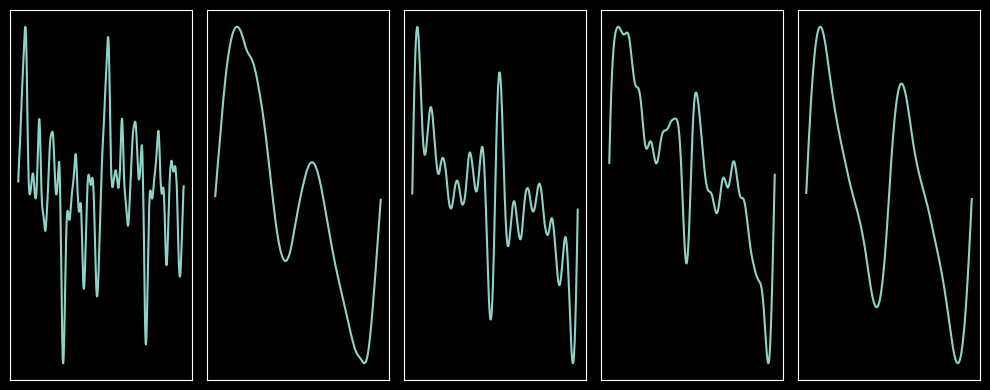

scores: [np.float64(11.073630566908436), np.float64(22.9376694845355), np.float64(191.3092128967603), np.float64(364.09170201271684), np.float64(960.3461323335318)]


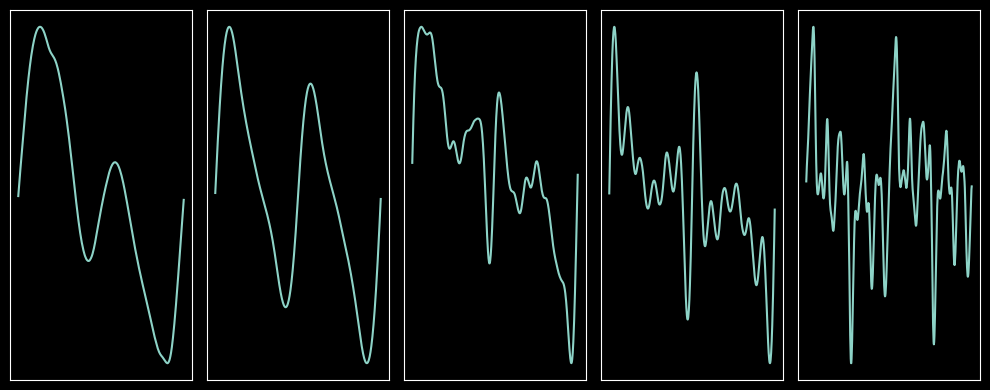

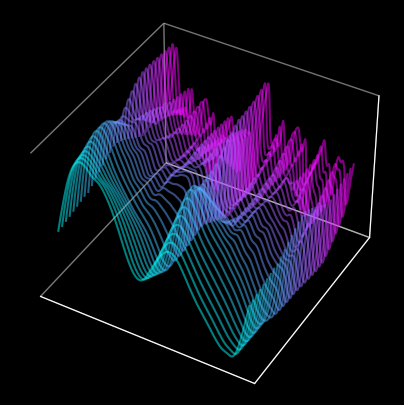

In [52]:
import os
import random

def pick_waves(folder, num=5):
    all_files = [f for f in os.listdir(folder) if f.endswith(".wav")]
    random_files = random.sample(all_files, num)
    waves = []
    
    for f in random_files:
        sr, wave = wavfile.read(os.path.join(folder, f))
        if len(wave.shape) == 2 and wave.shape[1] == 2:
            wave_mono = np.mean(wave, axis=1, dtype=wave.dtype)
            waves.append(wave_mono)
        else:
            waves.append(wave)
    
    return waves

waves = pick_waves("./waveforms/AKWF_eorgan/")
    
fig, axs = plt.subplots(1, 5, figsize=(10,4))
for i in range(5):
    axs[i].plot(waves[i])
    axs[i].set_xticks([])  # remove x-axis ticks
    axs[i].set_yticks([])  # remove y-axis ticks
plt.tight_layout()
plt.show()

waves, scores = sort_waves(waves)
print('scores:', scores)

fig, axs = plt.subplots(1, 5, figsize=(10,4))
for i in range(5):
    axs[i].plot(waves[i])
    axs[i].set_xticks([])  # remove x-axis ticks
    axs[i].set_yticks([])  # remove y-axis ticks
plt.tight_layout()
plt.show()
    
tables = morph_multiple(waves)

plot_wavetable(tables, 0.5)

C:\Users\tiago\AppData\Local\Temp\ipykernel_15288\815827970.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, wave = wavfile.read(os.path.join(folder, f))


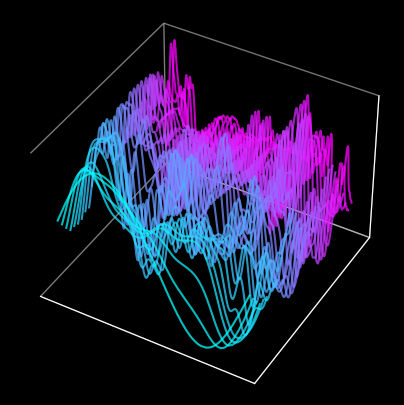

In [139]:
import numpy as np
from scipy.io import wavfile
import os

def export_wavetable(wavetables, folder, base_name, sample_rate=44100):
    os.makedirs(folder, exist_ok=True)
    wavetables = np.array(wavetables)
    wavetable_float32 = wavetables.flatten().astype(np.float32)
    wavetable_float32 /= np.max(np.abs(wavetable_float32))  # normalize [-1,1]
    filename = os.path.join(folder, f"{base_name}.wav")
    wavfile.write(filename, sample_rate, wavetable_float32)


numwaveforms = 8 # number of waveforms to concatenate
numsteps = 4 # number of spectral morphing frames between the waveforms

waves = pick_waves('./waveforms/AKWF_clavinet/', numwaveforms + 1)
waves, _ = sort_waves(waves)
tables = morph_multiple(waves, numsteps)

export_wavetable(tables, "./exported", "_1")
plot_wavetable(tables)

C:\Users\tiago\AppData\Local\Temp\ipykernel_15288\815827970.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, wave = wavfile.read(os.path.join(folder, f))


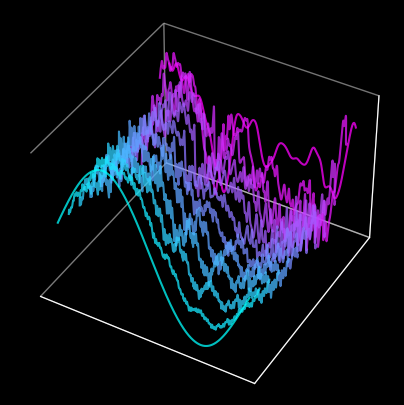

In [162]:
# blended waveforms from multiple folders

numsteps = 4

waves1 = pick_waves('./waveforms/AKWF_ebass/', 1)
waves2 = pick_waves('./waveforms/AKWF_piano/', 1)
waves3 = pick_waves('./waveforms/AKWF_granular/', 1)
waves4 = pick_waves('./waveforms/AKWF_snippets/', 1)

waves = waves1 + waves2 + waves3 + waves4

waves, _ = sort_waves(waves)
tables = morph_multiple(waves, numsteps)

export_wavetable(tables, "./exported", "_1")
plot_wavetable(tables)